In [1]:
import numpy as np
import pandas as pd 
import torch 
from torch import nn 
import torchvision 
from datasets import load_dataset
from diffusers import DDIMScheduler,DDPMPipeline
import matplotlib.pyplot as plt 
from torchvision import transforms
from tqdm.auto import tqdm 
from torch.utils.data import DataLoader
from PIL import Image

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Working on device : {device}")

Working on device : cuda


In [68]:
img_pipeline = DDPMPipeline.from_pretrained("google/ddpm-celebahq-256")
img_pipeline.to(device)

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "google/ddpm-celebahq-256",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

**Loading a Image Pipeline.**

In [5]:
images = img_pipeline().images
images

  0%|          | 0/1000 [00:00<?, ?it/s]

[<PIL.Image.Image image mode=RGB size=256x256>]

# Using DDPM Scheduler

In [63]:
scheduler = DDIMScheduler.from_pretrained('google/ddpm-celebahq-256')
scheduler.set_timesteps(num_inference_steps = 40)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


0it [00:00, ?it/s]

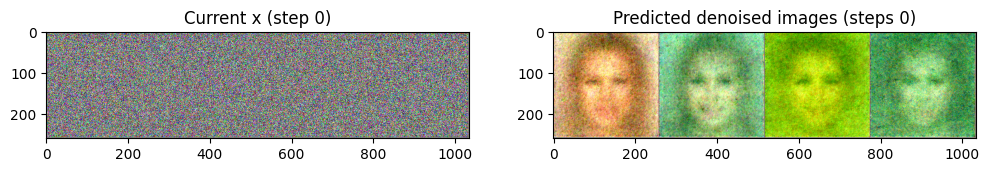

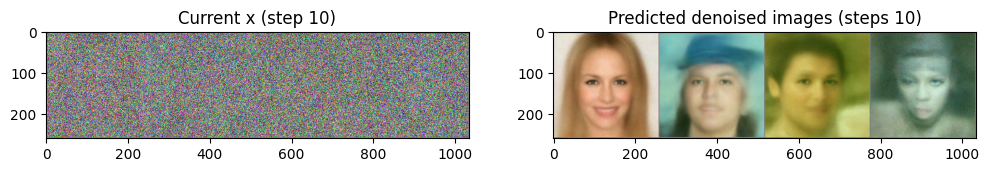

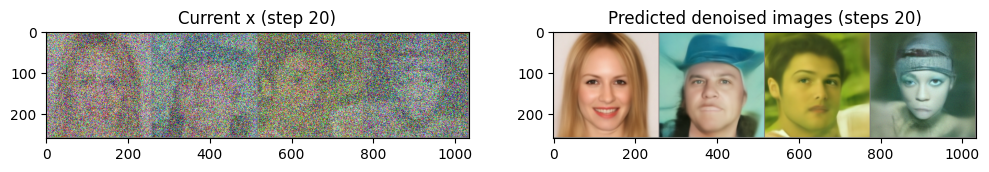

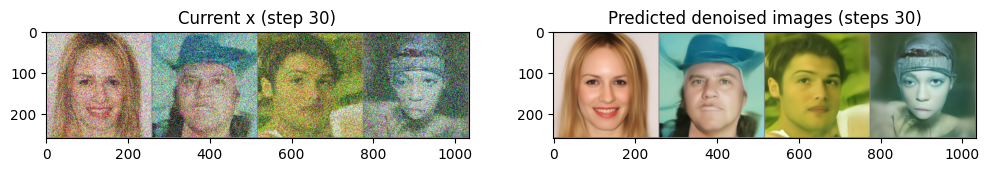

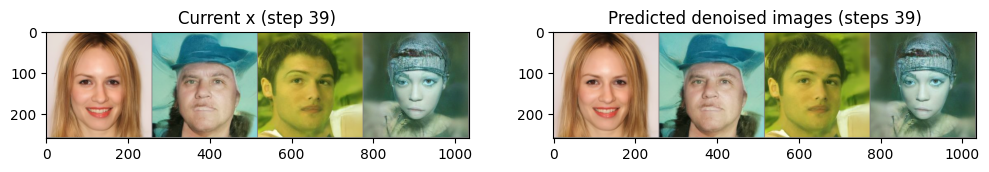

In [17]:
x = torch.randn(4,3,256,256).to(device)
for i,t in tqdm(enumerate(scheduler.timesteps)):
    model_input = scheduler.scale_model_input(x,t)

    with torch.no_grad():
        noise_pred = img_pipeline.unet(model_input,t)['sample']
    scheduler_output = scheduler.step(noise_pred,t,x)
    x = scheduler_output.prev_sample

    if i%10 == 0 or i == len(scheduler.timesteps)-1:
        fig,axs = plt.subplots(1,2,figsize=(12,5))

        grid = torchvision.utils.make_grid(x,nrow=4).permute(1,2,0)
        axs[0].imshow(grid.cpu().clip(-1,1)*0.5+0.5)
        axs[0].set_title(f"Current x (step {i})")

        pred_x0 = (scheduler_output.pred_original_sample)
        grid = torchvision.utils.make_grid(pred_x0,nrow=4).permute(1,2,0)
        axs[1].imshow(grid.cpu().clip(-1,1)*0.5+0.5)
        axs[1].set_title(f"Predicted denoised images (steps {i})")
        plt.show()

  0%|          | 0/40 [00:00<?, ?it/s]

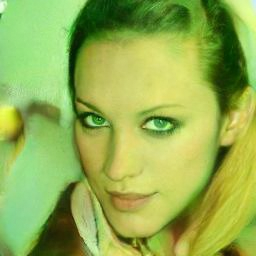

In [18]:
img_pipeline.scheduler = scheduler
images = img_pipeline(num_inference_steps=40).images
images[0]

# Fine-tuning a pre-trained Diffusion model

In [29]:
dataset_name = "ffkatya/naruto_train"
dataset = load_dataset(dataset_name,split='train')
dataset = dataset.remove_columns('text')
dataset

Dataset({
    features: ['image'],
    num_rows: 915
})

In [32]:
image_size = 128
batch_size = 8
data_transforms = transforms.Compose(
    [
        transforms.Resize((image_size,image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5],[0.5]),
    ]
)

In [54]:
def apply_transform(examples):
    images = [data_transforms(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}
    
dataset.set_transform(apply_transform)
print(f"Transforms applied successfully.")

Transforms applied successfully.


In [55]:
train_dataloader = DataLoader(
    dataset,
    batch_size = batch_size,
    shuffle = True,
)

previewing dataset


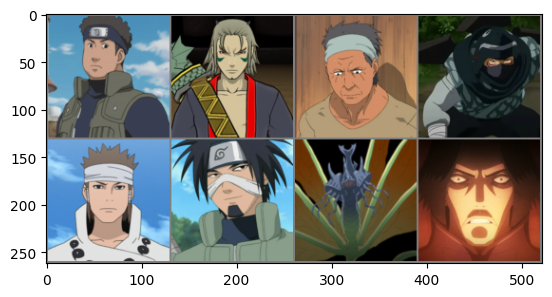

In [57]:
print("previewing dataset")
batch = next(iter(train_dataloader))
grid = torchvision.utils.make_grid(batch["images"], nrow=4)
plt.imshow(grid.permute(1,2,0).cpu().clip(-1,1)*0.5+0.5)
plt.show()

  0%|          | 0/115 [00:00<?, ?it/s]

Epoch 0 average loss: 1.002254737460095


  0%|          | 0/115 [00:00<?, ?it/s]

Epoch 1 average loss: 1.000197232287863


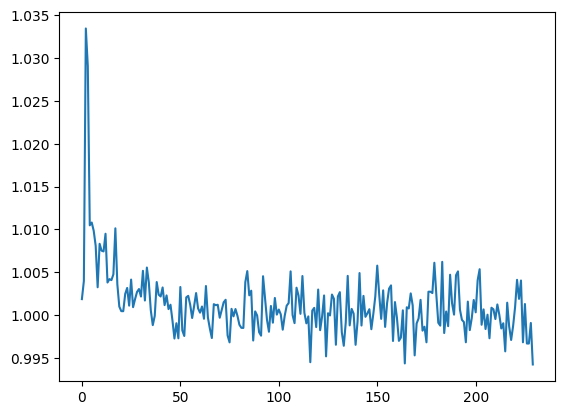

In [71]:
Epochs = 2
learning_rate = 0.0002
grad_acc_steps = 2 
optimizer = torch.optim.AdamW(img_pipeline.unet.parameters(),lr=learning_rate)

losses = []

for epoch in range(Epochs):
    for step,batch in tqdm(enumerate(train_dataloader),total=len(train_dataloader)):
        clean_images = batch['images'].to(device)
        noise = torch.randn(clean_images.shape).to(clean_images.device)
        batch_size = clean_images.shape[0]

        timesteps = torch.randint(
            0,
            img_pipeline.scheduler.num_train_timesteps,
            (batch_size,),
            device = clean_images.device,
        ).long()

        noisy_image = img_pipeline.scheduler.add_noise(clean_images,noise,timesteps)
        noise_preds = img_pipeline.unet(noisy_image,timesteps,return_dict=False)[0]
        loss = torch.nn.functional.mse_loss(
            noise_preds,noise
        )
        losses.append(loss.item())
        loss.backward(loss)
        if (step + 1) % grad_acc_steps == 0:
            optimizer.step()
            optimizer.zero_grad()
    print(f"Epoch {epoch} average loss: {sum(losses[-len(train_dataloader):])/len(train_dataloader)}")
plt.plot(losses)

# Applying Guidance to Diffusion Models

model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

0it [00:00, ?it/s]

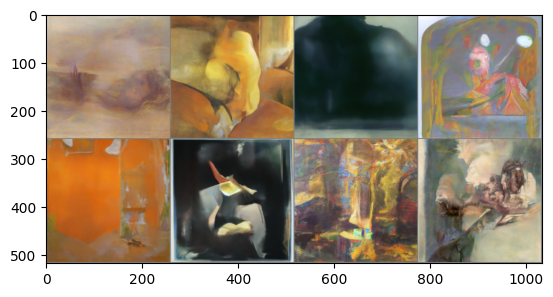

In [74]:
 pipeline_name = "johnowhitaker/sd-class-wikiart-from-bedrooms"
 image_pipe = DDPMPipeline.from_pretrained(pipeline_name).to(device)

 scheduler = DDIMScheduler.from_pretrained(pipeline_name)
 scheduler.set_timesteps(num_inference_steps=40)

 x = torch.randn(8, 3, 256, 256).to(device)

 for i, t in tqdm(enumerate(scheduler.timesteps)):
     model_input = scheduler.scale_model_input(x, t)
     with torch.no_grad():
         noise_pred = image_pipe.unet(model_input, t)["sample"]
     x = scheduler.step(noise_pred, t, x).prev_sample

 grid = torchvision.utils.make_grid(x, nrow=4)
 plt.imshow(grid.permute(1, 2, 0).cpu().clip(-1, 1) * 0.5 + 0.5);

In [76]:
def color_loss(images, target_color=(0.1, 0.9, 0.5)):
    target = (torch.tensor(target_color).to(images.device) * 2 - 1)  
    target = target[None, :, None, None]  
    error = torch.abs(images - target).mean()  
    return error

0it [00:00, ?it/s]

0 loss: 3.4111175537109375
10 loss: 2.915329933166504
20 loss: 2.8976688385009766
30 loss: 2.9135866165161133


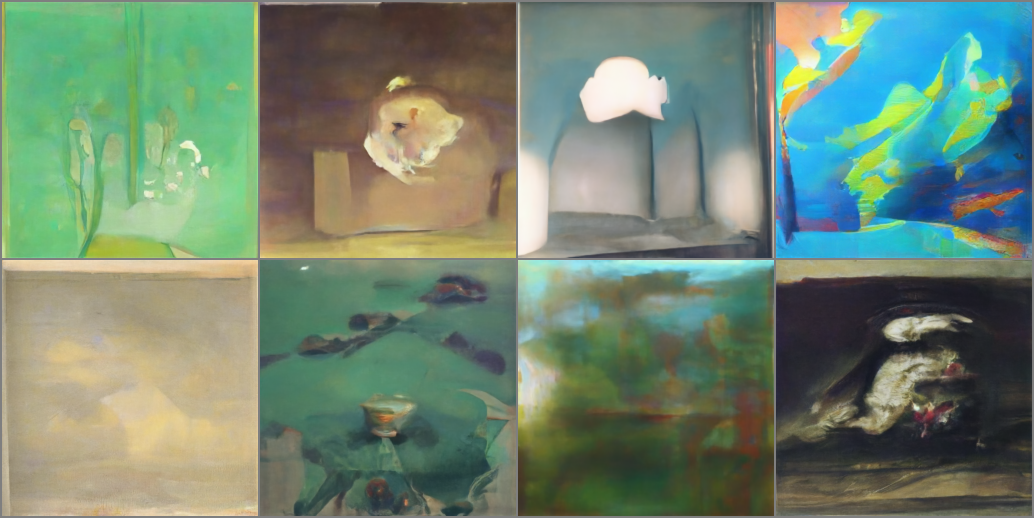

In [81]:
guidance_loss_scale = 5  
x = torch.randn(8, 3, 256, 256).to(device)

for i, t in tqdm(enumerate(scheduler.timesteps)):
    model_input = scheduler.scale_model_input(x, t)
    with torch.no_grad():
        noise_pred = image_pipe.unet(model_input, t)["sample"]
    x = x.detach().requires_grad_()
    x0 = scheduler.step(noise_pred, t, x).pred_original_sample
    loss = color_loss(x0) * guidance_loss_scale
    if i % 10 == 0:
        print(i, "loss:", loss.item())
    cond_grad = -torch.autograd.grad(loss, x)[0]
    x = x.detach() + cond_grad
    x = scheduler.step(noise_pred, t, x).prev_sample

grid = torchvision.utils.make_grid(x, nrow=4)
im = grid.permute(1, 2, 0).cpu().clip(-1, 1) * 0.5 + 0.5
Image.fromarray(np.array(im * 255).astype(np.uint8))

# CLIP Guidance

In [86]:
pip install open-clip-torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [87]:
# @markdown load a CLIP model and define the loss function
import open_clip

clip_model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
clip_model.to(device)

tfms = torchvision.transforms.Compose(
    [
        torchvision.transforms.RandomResizedCrop(224),  
        torchvision.transforms.RandomAffine(
            5
        ), 
        torchvision.transforms.RandomHorizontalFlip(), 
        torchvision.transforms.Normalize(
            mean=(0.48145466, 0.4578275, 0.40821073),
            std=(0.26862954, 0.26130258, 0.27577711),
        ),
    ]
)

def clip_loss(image, text_features):
    image_features = clip_model.encode_image(
        tfms(image)
    ) 
    input_normed = torch.nn.functional.normalize(image_features.unsqueeze(1), dim=2)
    embed_normed = torch.nn.functional.normalize(text_features.unsqueeze(0), dim=2)
    dists = (
        input_normed.sub(embed_normed).norm(dim=2).div(2).arcsin().pow(2).mul(2)
    )  
    return dists.mean()

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


/tmp/ipykernel_55/3501076886.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


0it [00:00, ?it/s]

Step: 0 , Guidance loss: 45.615325927734375
Step: 25 , Guidance loss: 42.00756072998047
Step: 50 , Guidance loss: 39.74671173095703
Step: 75 , Guidance loss: 39.028785705566406


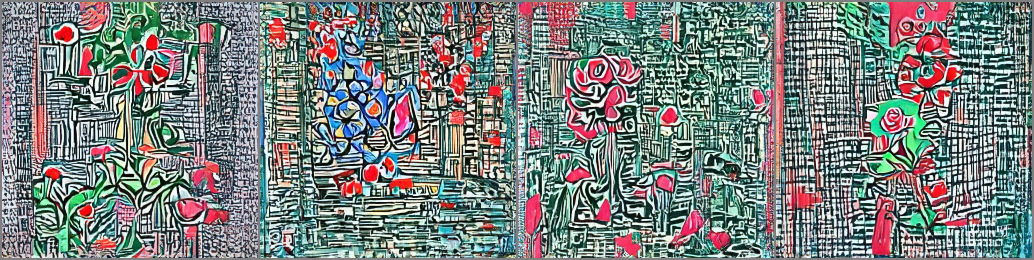

In [94]:
prompt = "Red Rose (still life), red flower painting" 
guidance_scale = 50  
n_cuts = 4 
scheduler.set_timesteps(100)

text = open_clip.tokenize([prompt]).to(device)
with torch.no_grad(), torch.cuda.amp.autocast():
    text_features = clip_model.encode_text(text)
x = torch.randn(4, 3, 256, 256).to(device)  

for i, t in tqdm(enumerate(scheduler.timesteps)):

    model_input = scheduler.scale_model_input(x, t)
    with torch.no_grad():
        noise_pred = image_pipe.unet(model_input, t)["sample"]

    cond_grad = 0

    for cut in range(n_cuts):
        x = x.detach().requires_grad_()
        x0 = scheduler.step(noise_pred, t, x).pred_original_sample
        loss = clip_loss(x0, text_features) * guidance_scale

        cond_grad -= torch.autograd.grad(loss, x)[0] / n_cuts

    if i % 25 == 0:
        print("Step:", i, ", Guidance loss:", loss.item())

    alpha_bar = scheduler.alphas_cumprod[i]
    x = (
        x.detach() + cond_grad * alpha_bar.sqrt()
    ) 

    x = scheduler.step(noise_pred, t, x).prev_sample


grid = torchvision.utils.make_grid(x.detach(), nrow=4)
im = grid.permute(1, 2, 0).cpu().clip(-1, 1) * 0.5 + 0.5
Image.fromarray(np.array(im * 255).astype(np.uint8))